In [3]:
import kagglehub
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")
print(path)

Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
/kaggle/input/formula-1-world-championship-1950-2020


In [4]:
import pandas as pd

lap_times = pd.read_csv(f"{path}/lap_times.csv")
pit_stops = pd.read_csv(f"{path}/pit_stops.csv")
races = pd.read_csv(f"{path}/races.csv")
results = pd.read_csv(f"{path}/results.csv")

In [5]:
race_id = 1021  # 2019 Hungarian GP

race_laps = lap_times[lap_times['raceId'] == race_id]
race_pit_stops = pit_stops[pit_stops['raceId'] == race_id]
race_results = results[results['raceId'] == race_id]

print("Total laps recorded:", len(race_laps))
print("Number of drivers:", race_laps['driverId'].nunique())
print(race_results[['driverId', 'positionOrder', 'points']].sort_values('positionOrder').head(10))

Total laps recorded: 1358
Number of drivers: 20
       driverId  positionOrder  points
24420         1              1    25.0
24421       830              2    19.0
24422        20              3    15.0
24423       844              4    12.0
24424       832              5    10.0
24425       842              6     8.0
24426         8              7     6.0
24427       822              8     4.0
24428       846              9     2.0
24429       848             10     1.0


In [6]:
selected_drivers = [1, 830, 20, 844, 832, 842, 8, 822]
race_laps = race_laps[race_laps['driverId'].isin(selected_drivers)]

print("Laps remaining after driver filter:", len(race_laps))
print(race_laps.head(10))


Laps remaining after driver filter: 556
        raceId  driverId  lap  position      time  milliseconds
461468    1021       830    1         1  1:25.604         85604
461469    1021       830    2         1  1:21.854         81854
461470    1021       830    3         1  1:21.863         81863
461471    1021       830    4         1  1:21.763         81763
461472    1021       830    5         1  1:21.542         81542
461473    1021       830    6         1  1:21.686         81686
461474    1021       830    7         1  1:21.611         81611
461475    1021       830    8         1  1:21.391         81391
461476    1021       830    9         1  1:21.545         81545
461477    1021       830   10         1  1:21.571         81571


In [7]:
print(race_laps['driverId'].value_counts())


driverId
830    70
1      70
844    70
20     70
822    69
832    69
8      69
842    69
Name: count, dtype: int64


In [8]:
#remove pit Stop
# get the lap number of every pit stop for our selected drivers
pit_laps = race_pit_stops[race_pit_stops['driverId'].isin(selected_drivers)][['driverId', 'lap']]
print(pit_laps)


      driverId  lap
7146       822    5
7154       830   25
7155       844   27
7157       842   28
7159       832   29
7160         8   29
7161         1   31
7164        20   39
7165       822   46
7167         1   48
7169       830   67


In [9]:
# collect every (driverId, lap) pair that needs removing: the pit lap itself + the lap right after
laps_to_remove = set()

for _, row in pit_laps.iterrows():
    driver = row['driverId']
    pit_lap = row['lap']
    laps_to_remove.add((driver, pit_lap))       # the pit-stop lap itself
    laps_to_remove.add((driver, pit_lap + 1))   # the lap right after

print("Total (driver, lap) pairs marked for removal:", len(laps_to_remove))

# now remove them from race_laps
before_count = len(race_laps)

race_laps['drop_flag'] = race_laps.apply(lambda r: (r['driverId'], r['lap']) in laps_to_remove, axis=1)
race_laps_clean = race_laps[~race_laps['drop_flag']].drop(columns='drop_flag')

after_count = len(race_laps_clean)
print(f"Removed {before_count - after_count} laps (pit + post-pit). Remaining: {after_count}")


Total (driver, lap) pairs marked for removal: 22
Removed 22 laps (pit + post-pit). Remaining: 534


In [10]:
# calculate each driver's median lap time (in milliseconds)
driver_medians = race_laps_clean.groupby('driverId')['milliseconds'].median()
print(driver_medians)


driverId
1      81275.0
8      82729.0
20     82419.5
822    82069.0
830    81366.0
832    82598.0
842    82426.0
844    82137.5
Name: milliseconds, dtype: float64


In [11]:
# attach each driver's median lap time onto every one of their laps
race_laps_clean = race_laps_clean.merge(
    driver_medians.rename('driver_median_ms'),
    on='driverId'
)

print(race_laps_clean.head())

   raceId  driverId  lap  position      time  milliseconds  driver_median_ms
0    1021       830    1         1  1:25.604         85604           81366.0
1    1021       830    2         1  1:21.854         81854           81366.0
2    1021       830    3         1  1:21.863         81863           81366.0
3    1021       830    4         1  1:21.763         81763           81366.0
4    1021       830    5         1  1:21.542         81542           81366.0


In [12]:
# calculate each row's personal cutoff = their median x 1.5
race_laps_clean['slow_cutoff'] = race_laps_clean['driver_median_ms'] * 1.5

# keep only laps that are NOT slower than that cutoff
before_count = len(race_laps_clean)
race_laps_clean = race_laps_clean[race_laps_clean['milliseconds'] <= race_laps_clean['slow_cutoff']]
after_count = len(race_laps_clean)

print(f"Removed {before_count - after_count} outlier-slow laps. Remaining: {after_count}")


Removed 0 outlier-slow laps. Remaining: 534


In [13]:

def calculate_tire_age(row, pit_laps_dict):
    driver = row['driverId']
    lap = row['lap']

    # get this driver's pit laps, sorted
    driver_pits = sorted(pit_laps_dict.get(driver, []))

    # find the most recent pit stop before this lap
    last_pit = 0
    for pit_lap in driver_pits:
        if pit_lap <= lap:
            last_pit = pit_lap
        else:
            break

    return lap - last_pit

# build a dictionary: driver -> list of laps they pitted on
pit_laps_dict = pit_laps.groupby('driverId')['lap'].apply(list).to_dict()

race_laps_clean['tire_age'] = race_laps_clean.apply(
    lambda row: calculate_tire_age(row, pit_laps_dict), axis=1
)

print(race_laps_clean[['driverId', 'lap', 'tire_age']].head(15))


    driverId  lap  tire_age
0        830    1         1
1        830    2         2
2        830    3         3
3        830    4         4
4        830    5         5
5        830    6         6
6        830    7         7
7        830    8         8
8        830    9         9
9        830   10        10
10       830   11        11
11       830   12        12
12       830   13        13
13       830   14        14
14       830   15        15


In [14]:
print(race_laps_clean[(race_laps_clean['driverId'] == 830) & (race_laps_clean['lap'] >= 22) & (race_laps_clean['lap'] <= 30)][['driverId', 'lap', 'tire_age']])


    driverId  lap  tire_age
21       830   22        22
22       830   23        23
23       830   24        24
24       830   27         2
25       830   28         3
26       830   29         4
27       830   30         5


In [15]:
# tire age squared - captures non-linear degradation
race_laps_clean['tire_age_squared'] = race_laps_clean['tire_age'] ** 2

# laps remaining - proxy for fuel burning off (lighter car = faster)
total_laps = race_laps_clean['lap'].max()
race_laps_clean['laps_remaining'] = total_laps - race_laps_clean['lap']

print(race_laps_clean[['driverId', 'lap', 'tire_age', 'tire_age_squared', 'laps_remaining']].head(10))


   driverId  lap  tire_age  tire_age_squared  laps_remaining
0       830    1         1                 1              69
1       830    2         2                 4              68
2       830    3         3                 9              67
3       830    4         4                16              66
4       830    5         5                25              65
5       830    6         6                36              64
6       830    7         7                49              63
7       830    8         8                64              62
8       830    9         9                81              61
9       830   10        10               100              60


In [16]:
race_laps_clean = race_laps_clean.sort_values(['driverId', 'lap']).reset_index(drop=True)

driver_pit_dict = pit_laps.groupby('driverId')['lap'].apply(list).to_dict()

def get_stint(row, driver_pit_laps):
    pits_before = [p for p in driver_pit_laps if p < row['lap']]
    return len(pits_before)

race_laps_clean['stint'] = race_laps_clean.apply(
    lambda row: get_stint(row, driver_pit_dict.get(row['driverId'], [])), axis=1
)

max_stint_per_driver = race_laps_clean.groupby('driverId')['stint'].transform('max')

test_data = race_laps_clean[race_laps_clean['stint'] == max_stint_per_driver]
train_data = race_laps_clean[race_laps_clean['stint'] != max_stint_per_driver]

print("Train laps:", len(train_data))
print("Test laps:", len(test_data))

# verify zero leakage
overlap_check = set(zip(train_data['driverId'], train_data['lap'])) & set(zip(test_data['driverId'], test_data['lap']))
print("Overlapping laps between train/test:", len(overlap_check))

Train laps: 299
Test laps: 235
Overlapping laps between train/test: 0


In [17]:
print(test_data.groupby('driverId')['lap'].count())


driverId
1      21
8      39
20     30
822    22
830     2
832    39
842    40
844    42
Name: lap, dtype: int64


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# BASELINE MODEL: grid position + lap number only
# (we don't have grid position in this table yet - let's add it from race_results)
grid_lookup = race_results.set_index('driverId')['grid'].to_dict()

train_data = train_data.copy()
test_data = test_data.copy()
train_data['grid'] = train_data['driverId'].map(grid_lookup)
test_data['grid'] = test_data['driverId'].map(grid_lookup)

baseline_features = ['grid', 'lap']
full_features = ['grid', 'lap', 'tire_age', 'tire_age_squared', 'laps_remaining']

X_train_base = train_data[baseline_features]
X_test_base = test_data[baseline_features]
X_train_full = train_data[full_features]
X_test_full = test_data[full_features]

y_train = train_data['milliseconds']
y_test = test_data['milliseconds']

print(X_train_base.head())
print(X_train_full.head())

   grid  lap
0     3    1
1     3    2
2     3    3
3     3    4
4     3    5
   grid  lap  tire_age  tire_age_squared  laps_remaining
0     3    1         1                 1              69
1     3    2         2                 4              68
2     3    3         3                 9              67
3     3    4         4                16              66
4     3    5         5                25              65


In [19]:
# Model 1: Linear Regression
lr_base = LinearRegression().fit(X_train_base, y_train)
lr_full = LinearRegression().fit(X_train_full, y_train)

# Model 2: Random Forest
rf_base = RandomForestRegressor(random_state=42).fit(X_train_base, y_train)
rf_full = RandomForestRegressor(random_state=42).fit(X_train_full, y_train)

# predictions
preds = {
    'Linear Regression - Baseline': lr_base.predict(X_test_base),
    'Linear Regression - Full (tire+fuel)': lr_full.predict(X_test_full),
    'Random Forest - Baseline': rf_base.predict(X_test_base),
    'Random Forest - Full (tire+fuel)': rf_full.predict(X_test_full),
}

# build comparison table
results_table = []
for name, pred in preds.items():
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    results_table.append({'Model': name, 'RMSE (ms)': round(rmse, 1), 'MAE (ms)': round(mae, 1)})

results_df = pd.DataFrame(results_table)
print(results_df)


                                  Model  RMSE (ms)  MAE (ms)
0          Linear Regression - Baseline      906.0     715.3
1  Linear Regression - Full (tire+fuel)     1089.2     845.3
2              Random Forest - Baseline     1215.2    1017.0
3      Random Forest - Full (tire+fuel)     1001.9     811.2


In [20]:
#tuning the random forest
best_rmse = float('inf')
best_params = None

for depth in [3, 5, 8, None]:
    for n_est in [50, 100, 200]:
        model = RandomForestRegressor(max_depth=depth, n_estimators=n_est, random_state=42)
        model.fit(X_train_full, y_train)
        pred = model.predict(X_test_full)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (depth, n_est)

print(f"Best RMSE: {best_rmse:.1f} with max_depth={best_params[0]}, n_estimators={best_params[1]}")


Best RMSE: 954.5 with max_depth=5, n_estimators=50


In [21]:
final_rf_full = RandomForestRegressor(max_depth=5, n_estimators=50, random_state=42).fit(X_train_full, y_train)
final_pred = final_rf_full.predict(X_test_full)

rmse_final = np.sqrt(mean_squared_error(y_test, final_pred))
mae_final = mean_absolute_error(y_test, final_pred)

results_table.append({'Model': 'Random Forest - Full (Tuned)', 'RMSE (ms)': round(rmse_final, 1), 'MAE (ms)': round(mae_final, 1)})
results_df = pd.DataFrame(results_table)
print(results_df)


                                  Model  RMSE (ms)  MAE (ms)
0          Linear Regression - Baseline      906.0     715.3
1  Linear Regression - Full (tire+fuel)     1089.2     845.3
2              Random Forest - Baseline     1215.2    1017.0
3      Random Forest - Full (tire+fuel)     1001.9     811.2
4          Random Forest - Full (Tuned)      954.5     769.1


In [24]:
lr_features = ['grid', 'lap', 'tire_age']
rf_features = ['grid', 'lap', 'tire_age', 'tire_age_squared', 'laps_remaining']

X_train_lr = train_data[lr_features]
X_test_lr = test_data[lr_features]
X_train_rf = train_data[rf_features]
X_test_rf = test_data[rf_features]

lr_enhanced = LinearRegression().fit(X_train_lr, y_train)
rf_enhanced = RandomForestRegressor(max_depth=5, n_estimators=50, random_state=42).fit(X_train_rf, y_train)

lr_pred = lr_enhanced.predict(X_test_lr)
rf_pred = rf_enhanced.predict(X_test_rf)

print("Linear Regression Enhanced RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Random Forest Enhanced RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


Linear Regression Enhanced RMSE: 905.2511871885391
Random Forest Enhanced RMSE: 954.4698855714058


In [25]:
final_results = pd.DataFrame([
    {'Model': 'Linear Regression - Baseline', 'RMSE (ms)': 906.0},
    {'Model': 'Linear Regression - Enhanced (tire_age)', 'RMSE (ms)': round(np.sqrt(mean_squared_error(y_test, lr_pred)), 1)},
    {'Model': 'Random Forest - Baseline', 'RMSE (ms)': 1215.2},
    {'Model': 'Random Forest - Enhanced (tire+fuel, tuned)', 'RMSE (ms)': round(np.sqrt(mean_squared_error(y_test, rf_pred)), 1)},
])
print(final_results)

                                         Model  RMSE (ms)
0                 Linear Regression - Baseline      906.0
1      Linear Regression - Enhanced (tire_age)      905.3
2                     Random Forest - Baseline     1215.2
3  Random Forest - Enhanced (tire+fuel, tuned)      954.5


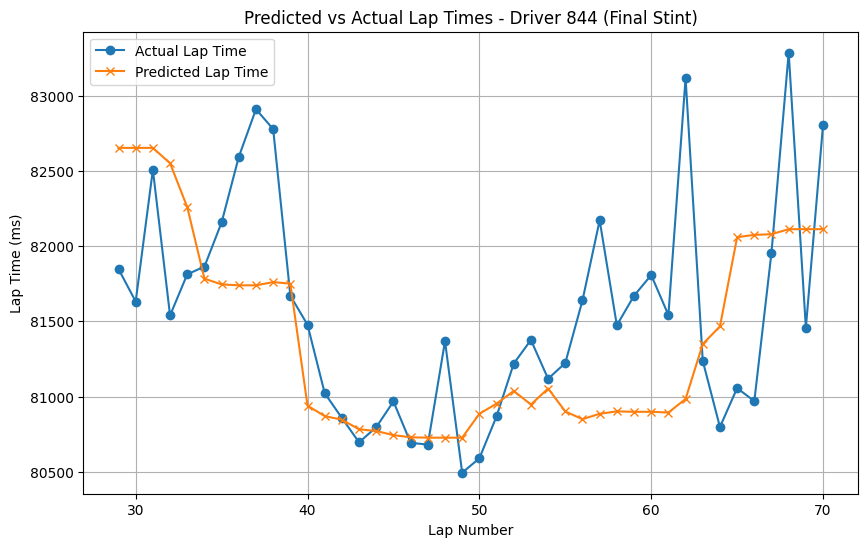

In [26]:
driver_id_to_plot = 844
driver_test = test_data[test_data['driverId'] == driver_id_to_plot].sort_values('lap')

X_driver_rf = driver_test[rf_features]
y_actual = driver_test['milliseconds']
y_predicted = rf_enhanced.predict(X_driver_rf)

plt.figure(figsize=(10, 6))
plt.plot(driver_test['lap'], y_actual, label='Actual Lap Time', marker='o')
plt.plot(driver_test['lap'], y_predicted, label='Predicted Lap Time', marker='x')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (ms)')
plt.title(f'Predicted vs Actual Lap Times - Driver {driver_id_to_plot} (Final Stint)')
plt.legend()
plt.grid(True)
plt.savefig('stint_plot.png')
plt.show()